In [1]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_score,recall_score,f1_score
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Srinu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
data=pd.read_csv('movie.zip')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


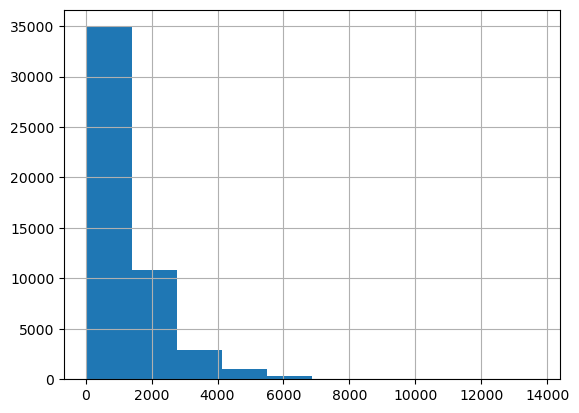

In [4]:
print(data['sentiment'].value_counts())

data['length']=data['review'].apply(len)
data['length'].hist()
plt.show()

In [5]:
stop_words=set(stopwords.words('english'))

def preprocess(text):
    text=text.lower()
    text=re.sub('<.*?>','',text)
    text=text.translate(str.maketrans('','',string.punctuation))
    words=text.split()
    words=[w for w in words if w not in stop_words]
    return ' '.join(words)

data['review']=data['review'].apply(preprocess)

In [7]:
pos_reviews=data[data['sentiment']=='positive']['review']
neg_reviews=data[data['sentiment']=='negative']['review']

total=len(data)
pos_count=len(pos_reviews)
neg_count=len(neg_reviews)

print("P(positive) =",pos_count/total)

pos_words=' '.join(pos_reviews).split()
neg_words=' '.join(neg_reviews).split()

V=len(set(pos_words+neg_words))

def word_prob(word,words_list):
    return (words_list.count(word)+1)/(len(words_list)+V)

print("P(great|positive) =",word_prob('great',pos_words))
print("P(terrible|negative) =",word_prob('terrible',neg_words))

P(positive) = 0.5
P(great|positive) = 0.0038886619853458586
P(terrible|negative) = 0.0008721170161986556


In [8]:
X=data['review']
y=data['sentiment']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
cv=CountVectorizer()
X_train_cv=cv.fit_transform(X_train)
X_test_cv=cv.transform(X_test)

model_cv=MultinomialNB()
model_cv.fit(X_train_cv,y_train)
pred_cv=model_cv.predict(X_test_cv)

print("Count Precision:",precision_score(y_test,pred_cv,pos_label='positive'))
print("Count Recall:",recall_score(y_test,pred_cv,pos_label='positive'))
print("Count F1:",f1_score(y_test,pred_cv,pos_label='positive'))

Count Precision: 0.8750769230769231
Count Recall: 0.8465965469339155
Count F1: 0.8606011700625378


In [10]:
tfidf=TfidfVectorizer()
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

model_tfidf=MultinomialNB()
model_tfidf.fit(X_train_tfidf,y_train)
pred_tfidf=model_tfidf.predict(X_test_tfidf)

print("TFIDF Precision:",precision_score(y_test,pred_tfidf,pos_label='positive'))
print("TFIDF Recall:",recall_score(y_test,pred_tfidf,pos_label='positive'))
print("TFIDF F1:",f1_score(y_test,pred_tfidf,pos_label='positive'))

TFIDF Precision: 0.8796824104234527
TFIDF Recall: 0.8575114109942449
TFIDF F1: 0.8684554316149131


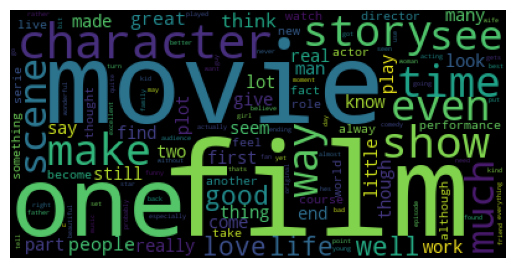

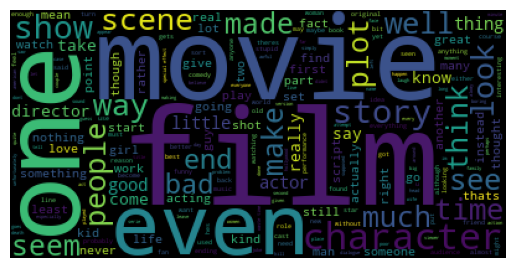

In [11]:
wc_pos=WordCloud().generate(' '.join(pos_reviews))
plt.imshow(wc_pos)
plt.axis('off')
plt.show()

wc_neg=WordCloud().generate(' '.join(neg_reviews))
plt.imshow(wc_neg)
plt.axis('off')
plt.show()